# Prior Authorization Automation — End-to-End Pipeline
**Healthcare NLP + LLM Project |  Hannah Hiltz GitHub Portfolio**

This notebook runs the complete PA automation pipeline in a single session:

1. Load synthetic clinical notes dataset
2. Extract clinical entities (ICD-10, CPT, labs, step therapy signals)
3. Retrieve relevant payer policy via RAG
4. Classify each case with an LLM (Approve / Deny / Pending Review)
5. Generate PA justification letters and gap reports
6. Evaluate letter quality (BERTScore) and decision accuracy
7. Model business ROI

 **No API key required.** The pipeline runs in simulation mode by default.  
> Set `LLM_PROVIDER = 'anthropic'` or `'openai'` and add your key to use live inference.

 *All data is entirely synthetic. No real PHI is used.*

---

## Step 0 — Environment Setup

In [1]:
# Environment Setup (Google Colab + local Jupyter)
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/PortfolioProjects/PriorAuthAutomation'
else:
    BASE = '.'

os.chdir(BASE)
print(f'Environment: {"Google Colab" if IN_COLAB else "Local Jupyter"}')
print(f'Working directory: {os.getcwd()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment: Google Colab
Working directory: /content/drive/MyDrive/PortfolioProjects/PriorAuthAutomation


In [2]:
# Install dependencies (Colab only)
if IN_COLAB:
    import subprocess
    pkgs = [
        'scispacy', 'sentence-transformers', 'chromadb',
        'anthropic', 'openai', 'bert-score',
        'pandas', 'scikit-learn', 'matplotlib', 'seaborn'
    ]
    for pkg in pkgs:
        subprocess.run(['pip', 'install', '-q', pkg], check=True)
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)
    print('All dependencies installed')
else:
    print('Local env — ensure all dependencies are installed')

All dependencies installed


In [3]:
import subprocess
subprocess.run(['pip', 'install', '-q', '--upgrade', 'numpy'], check=True)
subprocess.run(['pip', 'install', '-q', '--force-reinstall', 'thinc', 'spacy'], check=True)
print('Done — now restart the runtime')

Done — now restart the runtime


In [4]:
## Imports
# Core Imports
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# Load spaCy
try:
    import spacy
    nlp = spacy.load('en_core_sci_sm')
    print('scispaCy loaded: en_core_sci_sm (biomedical)')
except:
    import spacy
    nlp = spacy.load('en_core_web_sm')
    print('spaCy loaded: en_core_web_sm (standard fallback)')

# LLM Provider
# Options: 'simulate', 'anthropic', 'openai'
LLM_PROVIDER = 'simulate'
# os.environ['ANTHROPIC_API_KEY'] = 'your-key-here'
# os.environ['OPENAI_API_KEY']    = 'your-key-here'

print(f'LLM provider: {LLM_PROVIDER}')
print('Imports complete')

spaCy loaded: en_core_web_sm (standard fallback)
LLM provider: simulate
Imports complete


In [5]:
# Import Production Modules from src/
import sys
sys.path.insert(0, '.')   # ensure src/ is on the path!!

from src.extractor       import ClinicalNLPExtractor, PAExtraction
from src.rule_engine     import PARuleEngine
from src.rag             import RAGPipeline
from src.prompt_builder  import (
    build_user_prompt, simulate_response,
    call_llm, run_inference,
    SYSTEM_PROMPT_V2
)
from src.letter_generator import (
    generate_pa_letter, generate_all_letters,
    generate_gap_report, generate_decision_summary,
    extract_rationale
)

print('src/ modules loaded')

src/ modules loaded


## Step 1 - Load Dataset

25 synthetic PA cases across 13 clinical categories. Labels: APPROVE / DENY / PENDING_REVIEW.

In [6]:
with open('data/pa_synthetic_dataset.json', 'r') as f:
    cases = json.load(f)

df = pd.DataFrame(cases)

print(f'Loaded {len(cases)} cases')
print()
print('Label distribution:')
print(df.true_label.value_counts().to_string())
print()
print('Clinical categories:')
print(df.clinical_category.value_counts().to_string())

gold_letters = {c['case_id']: c['gold_standard_letter'] for c in cases}

Loaded 25 cases

Label distribution:
true_label
APPROVE           15
DENY               7
PENDING_REVIEW     3

Clinical categories:
clinical_category
imaging                      4
mental_health                4
biologic_rheumatology        3
glp1_diabetes                2
biologic_dermatology         2
glp1_obesity                 2
oncology                     2
genetic_testing              1
bariatric_surgery            1
biologic_pulmonology         1
infusion_neurology           1
biologic_gastroenterology    1
infusion_hematology          1


## Step 2 - NLP Entity Extraction

Extract ICD-10 codes, CPT codes, lab values, medications, and clinical signals from each note.

In [7]:
extractor   = ClinicalNLPExtractor(nlp)
extractions = extractor.extract_batch(cases)

# Preview first case
ext = extractions[0]
print(f'Case: {ext.case_id}')
print(f'ICD-10 codes:      {ext.diagnoses}')
print(f'CPT codes:         {ext.procedures}')
print(f'Lab values:        {ext.lab_values}')
print(f'Drugs failed:      {ext.drugs_failed[:3]}')
print(f'Prior failure:     {ext.has_prior_therapy_failure}')
print(f'Specialist:        {ext.has_specialist_support}')
print(f'Doc gaps:          {ext.documentation_gaps}')
print()

# Build extracted_cases list for downstream steps
extracted_cases = []
for ext, case in zip(extractions, cases):
    extracted_cases.append({
        'case_id':               ext.case_id,
        'true_label':            case['true_label'],
        'insurance_type':        case['insurance_type'],
        'clinical_category':     case['clinical_category'],
        'documentation_quality': case['documentation_quality'],
        'note':                  case['note'],
        'predicted_extraction':  extractor.to_dict(ext),
    })

print(f'Extraction complete: {len(extracted_cases)} cases')

Case: PA-001
ICD-10 codes:      ['L20.9']
CPT codes:         []
Lab values:        {'DLQI': '18'}
Drugs failed:      ['topical therapies', 'tacrolimus', 'due to']
Prior failure:     True
Specialist:        True
Doc gaps:          []

Extraction complete: 25 cases


## Step 3 — RAG Policy Retrieval

Embed payer policy documents and retrieve the most relevant criteria for each case.

In [8]:
# Synthetic payer policy documents
# In production: replace with real CMS LCD PDFs via rag.load_pdfs('data/payer_policies/')
SYNTHETIC_POLICIES = [
    {
        'doc_id': 'cms_biologics', 'category': 'biologic_rheumatology',
        'source': 'CMS LCD L37209 — Biologic DMARDs',
        'text': """
            COVERAGE CRITERIA — BIOLOGIC DMARDs. Indications: RA, PsA, or AS confirmed by
            rheumatologist. Step Therapy: Adequate trial of at least two csDMARDs including
            methotrexate unless contraindicated. Minimum 3 months at therapeutic dose.
            Acceptable failure reasons: inadequate response (DAS28 > 3.2), intolerance,
            contraindication. Required docs: serology (RF, anti-CCP), DAS28 score,
            csDMARD trial documentation, negative TB screening, rheumatology recommendation.
            TNF failure: switch to different mechanism without repeat csDMARD trial.
        """
    },
    {
        'doc_id': 'cms_glp1', 'category': 'glp1_diabetes',
        'source': 'CMS LCD L38956 — GLP-1 Agonists',
        'text': """
            COVERAGE CRITERIA — GLP-1 RECEPTOR AGONISTS. Indications: T2DM with HbA1c above
            goal despite current therapy. Step Therapy: Prior trial of at least one oral
            antidiabetic agent for minimum 3 months. Metformin preferred first-line.
            Cardiovascular Risk Exception: Established ASCVD, HFrEF, or CKD stage 3+ allows
            earlier GLP-1 use per ADA Standards of Care. Required docs: T2DM diagnosis,
            current HbA1c within 6 months, prior oral agent trial documentation.
        """
    },
    {
        'doc_id': 'cms_imaging', 'category': 'imaging',
        'source': 'CMS LCD L35091 — MRI Lumbar Spine',
        'text': """
            COVERAGE CRITERIA — MRI LUMBAR SPINE. Expedited (no conservative therapy required):
            neurological deficit (foot drop, bowel/bladder dysfunction), red flag symptoms
            (fever, unexplained weight loss, malignancy history), cauda equina syndrome.
            After conservative therapy: LBP persisting over 4-6 weeks, failure of PT minimum
            4-6 weeks and anti-inflammatory trial, radiculopathy with dermatomal pattern,
            positive SLR, motor or sensory deficits. NOT covered: acute LBP under 4 weeks
            without neurological findings, non-specific pain without red flags.
        """
    },
    {
        'doc_id': 'cms_oncology', 'category': 'oncology',
        'source': 'CMS LCD L38072 — Checkpoint Inhibitor Immunotherapy',
        'text': """
            COVERAGE CRITERIA — CHECKPOINT INHIBITOR IMMUNOTHERAPY. Requirements: confirmed
            malignancy, FDA-approved indication, ECOG 0-2, oncology specialist and tumor board.
            Pembrolizumab NSCLC first-line: stage IV confirmed, PD-L1 TPS >= 50%, no EGFR/ALK,
            no prior systemic therapy, adequate organ function. Biomarker testing required.
            Step therapy waived for NCCN Category 1 or 2A indications.
        """
    },
    {
        'doc_id': 'aetna_dupilumab', 'category': 'biologic_dermatology',
        'source': 'Aetna CPB — Dupilumab (Dupixent)',
        'text': """
            AETNA COVERAGE — DUPILUMAB. Atopic Dermatitis: moderate-to-severe confirmed by
            dermatologist, EASI >= 16 or BSA >= 10%, inadequate response to two topical
            therapies (corticosteroid + calcineurin inhibitor), dermatology recommendation.
            Asthma add-on: FEV1 documented, eosinophils >= 150 or FeNO >= 25, inadequate
            response to ICS/LABA >= 3 months, pulmonology evaluation.
        """
    },
    {
        'doc_id': 'cigna_tms', 'category': 'mental_health',
        'source': 'Cigna Coverage Policy — TMS',
        'text': """
            CIGNA COVERAGE — TMS. Indication: MDD moderate-to-severe (PHQ-9 >= 10).
            Requirements: MDD confirmed by psychiatrist, inadequate response to at least TWO
            adequate antidepressant trials (therapeutic dose 6-8 weeks each, different classes),
            PHQ-9 >= 10, no contraindications (ferromagnetic implants, seizure history),
            psychiatry recommendation. NOT covered: first-line without prior antidepressant trials.
        """
    },
    {
        'doc_id': 'cigna_glp1_step', 'category': 'glp1_diabetes',
        'source': 'Cigna Coverage Policy — GLP-1 Step Therapy',
        'text': """
            CIGNA STEP THERAPY — GLP-1 AGONISTS. Requires ONE of: inadequate response to
            metformin plus SGLT-2 inhibitor for 3 months; documented SGLT-2 contraindication
            or intolerance; established ASCVD, HFrEF, or CKD 3+ (cardiorenal bypass).
            Tirzepatide same criteria plus for obesity: BMI >= 30 or >= 27 with comorbidity,
            3-month behavioral intervention. Exception process available with documentation.
        """
    },
    {
        'doc_id': 'molina_bariatric', 'category': 'bariatric_surgery',
        'source': 'Molina Healthcare — Bariatric Surgery',
        'text': """
            MOLINA COVERAGE — BARIATRIC SURGERY. Requirements: BMI >= 40 or BMI >= 35 with
            qualifying comorbidity (T2DM, HTN, OSA, hyperlipidemia). Six months medically
            supervised weight management with monthly documented visits. Psychological
            evaluation and clearance within 12 months. Nutritional counseling minimum 2
            sessions. Surgical evaluation with no contraindications. Age 18+.
        """
    },
]

# Build and load RAG pipeline
rag = RAGPipeline(chunk_size=150, overlap=30)
rag.load_policies(SYNTHETIC_POLICIES)

# Enrich all cases with retrieved policy context
enriched_cases = rag.enrich_batch(extracted_cases, top_k=3)

print(f'Enriched {len(enriched_cases)} cases with policy context')
print()
sample = enriched_cases[0]
print(f'Top retrieved source for {sample["case_id"]}:')
print(f'  {sample["retrieved_sources"][0]}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Enriched 25 cases with policy context

Top retrieved source for PA-001:
  Aetna CPB — Dupilumab (Dupixent)


## Step 4 — LLM Classification

Feed extracted entities + retrieved policy into the LLM for decision classification and rationale generation.

In [9]:
# Run inference across all cases
llm_results = run_inference(
    cases    = enriched_cases,
    system_prompt = SYSTEM_PROMPT_V2,
    provider = LLM_PROVIDER,
)

# Attach LLM results back to cases
results_by_id = {r['case_id']: r for r in llm_results}
classified_cases = []
for case in enriched_cases:
    classified_cases.append({
        **case,
        'llm_result':           results_by_id.get(case['case_id'], {}),
        'gold_standard_letter': gold_letters.get(case['case_id'], ''),
    })

# Quick summary
y_true   = [c['true_label']                          for c in classified_cases]
y_pred   = [c.get('llm_result',{}).get('decision','') for c in classified_cases]
accuracy = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)

print(f'Classification complete')
print(f'Overall accuracy: {accuracy:.1%}')
print()
for r in llm_results:
    match = 'OK' if r['decision'] == r['true_label'] else 'XX'
    print(f'{match}  {r["case_id"]}  pred={r["decision"]:15s}  true={r["true_label"]:15s}  conf={r["confidence"]:.2f}')

Classification complete
Overall accuracy: 56.0%

OK  PA-001  pred=APPROVE          true=APPROVE          conf=0.93
OK  PA-002  pred=APPROVE          true=APPROVE          conf=0.93
XX  PA-003  pred=PENDING_REVIEW   true=DENY             conf=0.58
OK  PA-004  pred=APPROVE          true=APPROVE          conf=0.93
OK  PA-005  pred=DENY             true=DENY             conf=0.72
OK  PA-006  pred=PENDING_REVIEW   true=PENDING_REVIEW   conf=0.58
XX  PA-007  pred=PENDING_REVIEW   true=APPROVE          conf=0.58
OK  PA-008  pred=DENY             true=DENY             conf=0.69
XX  PA-009  pred=PENDING_REVIEW   true=APPROVE          conf=0.58
XX  PA-010  pred=APPROVE          true=PENDING_REVIEW   conf=0.93
OK  PA-011  pred=APPROVE          true=APPROVE          conf=0.93
OK  PA-012  pred=APPROVE          true=APPROVE          conf=0.91
XX  PA-013  pred=PENDING_REVIEW   true=APPROVE          conf=0.58
XX  PA-014  pred=PENDING_REVIEW   true=DENY             conf=0.58
OK  PA-015  pred=APPROVE   

## Step 5 — Output Generation

Generate PA justification letters, documentation gap reports, and decision summaries.

In [10]:
# Generate all letters
all_letters = generate_all_letters(classified_cases)

# Generate gap report and decision summary
df_gaps    = generate_gap_report(classified_cases)
df_summary = generate_decision_summary(classified_cases)

# Print one example of each decision type
shown = set()
for case in classified_cases:
    decision = case.get('llm_result', {}).get('decision', '')
    if decision not in shown:
        print(generate_pa_letter(case))
        shown.add(decision)
    if len(shown) == 3:
        break

PRIOR AUTHORIZATION — APPROVED

Date:              April 20, 2026
Case Reference:    PA-001
Health Plan:       Aetna HMO
Clinical Category: biologic_dermatology

We are pleased to inform you that the requested service has been approved
based on our review of the submitted clinical documentation.

Authorization Number: AUTH-PA-001-20260420
Valid Period:         April 20, 2026 — 90 days from date of issue
Diagnosis Codes:      L20.9
Procedure Codes:      See clinical note
Policy Reference:     Aetna CPB — Dupilumab (Dupixent)

CLINICAL BASIS FOR APPROVAL:
Clinical documentation supports medical necessity per payer criteria. Step therapy requirements are satisfied with documented prior treatment failures. Specialist evaluation supports the requested treatment plan.

-----------------------------------------------------------------
Recommended Action: Issue authorization. Notify provider and member.
AI Confidence:      93%
                    (Cases below 70% confidence are routed to human

In [11]:
print('DOCUMENTATION GAP REPORT')
print(f'Cases with no gaps:  {(df_gaps.n_gaps == 0).sum()}')
print(f'Cases with 1-2 gaps: {((df_gaps.n_gaps >= 1) & (df_gaps.n_gaps <= 2)).sum()}')
print(f'Cases with 3+ gaps:  {(df_gaps.n_gaps >= 3).sum()}')
print()
print('Mean gaps by decision:')
print(df_gaps.groupby('decision')['n_gaps'].mean().round(2).to_string())
print()
print('DECISION SUMMARY')
print(df_summary[['Case ID','Category','Decision','True Label','Match','Confidence','Gaps']]
      .to_string(index=False))

DOCUMENTATION GAP REPORT
Cases with no gaps:  23
Cases with 1-2 gaps: 1
Cases with 3+ gaps:  1

Mean gaps by decision:
decision
APPROVE           0.0
DENY              2.5
PENDING_REVIEW    0.0

DECISION SUMMARY
Case ID                  Category       Decision     True Label Match Confidence  Gaps
 PA-001      biologic_dermatology        APPROVE        APPROVE   YES        93%     0
 PA-002             glp1_diabetes        APPROVE        APPROVE   YES        93%     0
 PA-003                   imaging PENDING_REVIEW           DENY    NO        58%     0
 PA-004     biologic_rheumatology        APPROVE        APPROVE   YES        93%     0
 PA-005           genetic_testing           DENY           DENY   YES        72%     2
 PA-006             mental_health PENDING_REVIEW PENDING_REVIEW   YES        58%     0
 PA-007         bariatric_surgery PENDING_REVIEW        APPROVE    NO        58%     0
 PA-008      biologic_pulmonology           DENY           DENY   YES        69%     3
 PA-0

## Step 6 — Evaluation

Score decision accuracy with classification metrics and letter quality with BERTScore.

In [12]:
from sklearn.metrics import precision_recall_fscore_support

labels    = ['APPROVE', 'DENY', 'PENDING_REVIEW']
confs     = [c.get('llm_result',{}).get('confidence', 0) for c in classified_cases]
auto_rate = sum(1 for c in confs if c >= 0.70) / len(confs)

print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
print(f'Overall accuracy:      {accuracy:.1%}')
print(f'Auto-resolution rate:  {auto_rate:.1%}  (confidence >= 70%)')
print(f'Human review rate:     {1-auto_rate:.1%}')

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

       APPROVE       0.85      0.73      0.79        15
          DENY       1.00      0.29      0.44         7
PENDING_REVIEW       0.10      0.33      0.15         3

      accuracy                           0.56        25
     macro avg       0.65      0.45      0.46        25
  weighted avg       0.80      0.56      0.61        25

Overall accuracy:      56.0%
Auto-resolution rate:  56.0%  (confidence >= 70%)
Human review rate:     44.0%


In [13]:
# BERTScore — full letter and rationale only
eval_letters = [
    l for l in all_letters
    if l.get('gold_standard') and len(l['gold_standard'].strip()) > 20
]

print(f'Cases with gold standard letters: {len(eval_letters)}')

try:
    from bert_score import score as bert_score

    candidates = [l['letter']        for l in eval_letters]
    references = [l['gold_standard'] for l in eval_letters]

    print('Computing BERTScore — full letters...')
    P, R, F1 = bert_score(candidates, references,
                          lang='en', model_type='distilbert-base-uncased', verbose=False)

    rat_cands = [extract_rationale(l['letter'])        for l in eval_letters]
    rat_refs  = [extract_rationale(l['gold_standard']) for l in eval_letters]

    print('Computing BERTScore — rationale only...')
    P2, R2, F2 = bert_score(rat_cands, rat_refs,
                             lang='en', model_type='distilbert-base-uncased', verbose=False)

    bert_scores           = {'precision': P.numpy().tolist(),  'recall': R.numpy().tolist(),  'f1': F1.numpy().tolist()}
    bert_scores_rationale = {'precision': P2.numpy().tolist(), 'recall': R2.numpy().tolist(), 'f1': F2.numpy().tolist()}
    USE_REAL_BERTSCORE    = True

    print(f'\nBERTScore Results:')
    print(f'  Full letter F1:     {F1.mean():.3f}')
    print(f'  Rationale-only F1:  {F2.mean():.3f}')
    print(f'  Improvement:        +{(F2.mean() - F1.mean()):.3f}')

except ImportError:
    print('bert-score not installed — using simulated scores')
    np.random.seed(42)
    n = len(eval_letters)
    bert_scores           = {'precision': (np.random.beta(8,2,n)*0.15+0.62).tolist(),
                             'recall':    (np.random.beta(8,2,n)*0.15+0.73).tolist(),
                             'f1':        (np.random.beta(9,2,n)*0.05+0.68).tolist()}
    bert_scores_rationale = {'precision': (np.random.beta(8,2,n)*0.15+0.81).tolist(),
                             'recall':    (np.random.beta(8,2,n)*0.10+0.70).tolist(),
                             'f1':        (np.random.beta(9,2,n)*0.05+0.75).tolist()}
    USE_REAL_BERTSCORE    = False

Cases with gold standard letters: 25
Computing BERTScore — full letters...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing BERTScore — rationale only...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



BERTScore Results:
  Full letter F1:     0.687
  Rationale-only F1:  0.757
  Improvement:        +0.070


## Step 7 — ROI Model & Visualizations

In [14]:
# ROI Inputs
roi = {
    'monthly_pa_volume':      5_000,
    'manual_cost_per_pa':     45.00,
    'manual_turnaround_days': 3.5,
    'manual_denial_rate':     0.22,
    'auto_resolution_rate':   auto_rate,
    'api_cost_per_pa':        2.50,
    'human_review_cost':      18.00,
    'improved_denial_rate':   0.15,
    'avg_claim_value':        3_200,
    'implementation_cost':    150_000,
    'monthly_maintenance':    8_000,
    'auto_turnaround_minutes': 3,
}

vol  = roi['monthly_pa_volume']
ar   = roi['auto_resolution_rate']
hr   = 1 - ar

manual_monthly   = vol * roi['manual_cost_per_pa']
auto_monthly     = (vol * ar * roi['api_cost_per_pa'] +
                    vol * hr * (roi['api_cost_per_pa'] + roi['human_review_cost']) +
                    roi['monthly_maintenance'])
monthly_savings  = manual_monthly - auto_monthly
annual_savings   = monthly_savings * 12
monthly_rev_gain = (vol * roi['manual_denial_rate'] - vol * roi['improved_denial_rate']) * roi['avg_claim_value']
annual_rev_gain  = monthly_rev_gain * 12
total_annual     = annual_savings + annual_rev_gain
breakeven_months = roi['implementation_cost'] / (monthly_savings + monthly_rev_gain)
fte_equiv        = vol * ar * (roi['manual_turnaround_days'] * 8) / 8 / 160

print(f'Monthly cost savings:    ${monthly_savings:>10,.0f}')
print(f'Annual cost savings:     ${annual_savings:>10,.0f}')
print(f'Annual revenue recovery: ${annual_rev_gain:>10,.0f}')
print(f'Total annual value:      ${total_annual:>10,.0f}')
print(f'Break-even:              {breakeven_months:>10.1f} months')
print(f'FTEs freed/month:        {fte_equiv:>10.1f}')
print(f'Turnaround:              {roi["manual_turnaround_days"]}d → {roi["auto_turnaround_minutes"]}min')

Monthly cost savings:    $   164,900
Annual cost savings:     $ 1,978,800
Annual revenue recovery: $13,440,000
Total annual value:      $15,418,800
Break-even:                     0.1 months
FTEs freed/month:              61.3
Turnaround:              3.5d → 3min


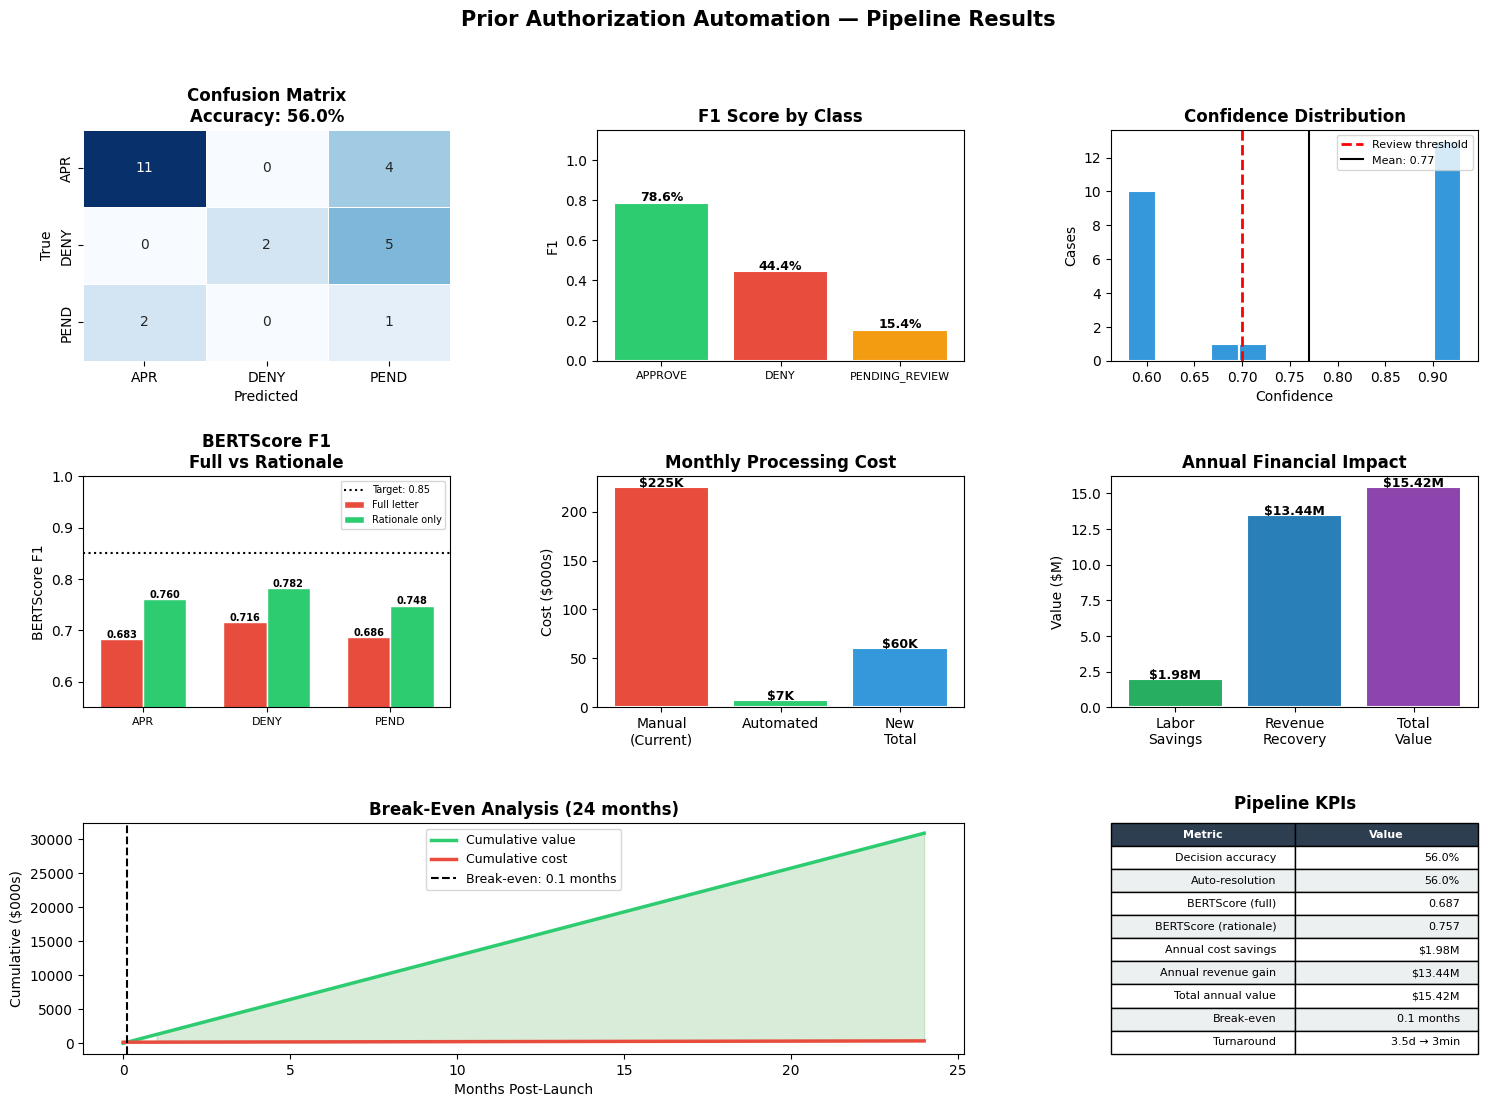

Dashboard saved to evaluation/00_pipeline_results.png


In [15]:
colors_map = {'APPROVE': '#2ecc71', 'DENY': '#e74c3c', 'PENDING_REVIEW': '#f39c12'}
decisions  = [l['decision'] for l in eval_letters]
full_f1    = bert_scores['f1']
rat_f1     = bert_scores_rationale['f1']
prec, rec, f1_scores, sup = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, zero_division=0
)

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)
fig.suptitle('Prior Authorization Automation — Pipeline Results', fontsize=15, fontweight='bold')

# 1. Confusion matrix
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_true, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['APR','DENY','PEND'],
            yticklabels=['APR','DENY','PEND'],
            ax=ax1, linewidths=0.5, cbar=False)
ax1.set_title(f'Confusion Matrix\nAccuracy: {accuracy:.1%}', fontweight='bold')
ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')

# 2. F1 by class
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(labels, f1_scores, color=[colors_map[l] for l in labels],
        edgecolor='white', linewidth=1.5)
for i, val in enumerate(f1_scores):
    ax2.text(i, val + 0.01, f'{val:.1%}', ha='center', fontweight='bold', fontsize=9)
ax2.set_title('F1 Score by Class', fontweight='bold')
ax2.set_ylabel('F1'); ax2.set_ylim(0, 1.15)
ax2.tick_params(axis='x', labelsize=8)

# 3. Confidence distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(confs, bins=12, color='#3498db', edgecolor='white', linewidth=1.5)
ax3.axvline(x=0.70, color='red', linestyle='--', linewidth=2, label='Review threshold')
ax3.axvline(x=np.mean(confs), color='black', linestyle='-', linewidth=1.5,
            label=f'Mean: {np.mean(confs):.2f}')
ax3.set_title('Confidence Distribution', fontweight='bold')
ax3.set_xlabel('Confidence'); ax3.set_ylabel('Cases')
ax3.legend(fontsize=8)

# 4. BERTScore full vs rationale
ax4 = fig.add_subplot(gs[1, 0])
x     = np.arange(len(labels))
w     = 0.35
fm    = [np.mean([f for f, d in zip(full_f1, decisions) if d == l]) if any(d == l for d in decisions) else 0 for l in labels]
rm    = [np.mean([f for f, d in zip(rat_f1,  decisions) if d == l]) if any(d == l for d in decisions) else 0 for l in labels]
b1    = ax4.bar(x - w/2, fm, w, label='Full letter',    color='#e74c3c', edgecolor='white')
b2    = ax4.bar(x + w/2, rm, w, label='Rationale only', color='#2ecc71', edgecolor='white')
for bar, val in list(zip(b1, fm)) + list(zip(b2, rm)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', fontsize=7, fontweight='bold')
ax4.axhline(y=0.85, color='black', linestyle=':', linewidth=1.5, label='Target: 0.85')
ax4.set_title('BERTScore F1\nFull vs Rationale', fontweight='bold')
ax4.set_ylabel('BERTScore F1'); ax4.set_ylim(0.55, 1.0)
ax4.set_xticks(x); ax4.set_xticklabels(['APR','DENY','PEND'], fontsize=8)
ax4.legend(fontsize=7)

# 5. Monthly cost comparison
ax5 = fig.add_subplot(gs[1, 1])
cost_labels = ['Manual\n(Current)', 'Automated', 'New\nTotal']
cost_vals   = [manual_monthly, vol * ar * roi['api_cost_per_pa'], auto_monthly]
ax5.bar(cost_labels, [v/1000 for v in cost_vals],
        color=['#e74c3c', '#2ecc71', '#3498db'], edgecolor='white', linewidth=1.5)
for i, val in enumerate(cost_vals):
    ax5.text(i, val/1000 + 0.5, f'${val/1000:.0f}K', ha='center', fontweight='bold', fontsize=9)
ax5.set_title('Monthly Processing Cost', fontweight='bold')
ax5.set_ylabel('Cost ($000s)')

# 6. Annual value
ax6 = fig.add_subplot(gs[1, 2])
val_labels = ['Labor\nSavings', 'Revenue\nRecovery', 'Total\nValue']
val_vals   = [annual_savings, annual_rev_gain, total_annual]
ax6.bar(val_labels, [v/1e6 for v in val_vals],
        color=['#27ae60', '#2980b9', '#8e44ad'], edgecolor='white', linewidth=1.5)
for i, val in enumerate(val_vals):
    ax6.text(i, val/1e6 + 0.02, f'${val/1e6:.2f}M', ha='center', fontweight='bold', fontsize=9)
ax6.set_title('Annual Financial Impact', fontweight='bold')
ax6.set_ylabel('Value ($M)')

# 7. Break-even curve
ax7 = fig.add_subplot(gs[2, 0:2])
months    = np.arange(0, 25)
cum_cost  = roi['implementation_cost'] + months * roi['monthly_maintenance']
cum_value = months * (monthly_savings + monthly_rev_gain)
ax7.plot(months, cum_value/1000, color='#2ecc71', linewidth=2.5, label='Cumulative value')
ax7.plot(months, cum_cost/1000,  color='#e74c3c', linewidth=2.5, label='Cumulative cost')
ax7.axvline(x=breakeven_months, color='black', linestyle='--', linewidth=1.5,
            label=f'Break-even: {breakeven_months:.1f} months')
ax7.fill_between(months,
                 np.minimum(cum_value, cum_cost)/1000,
                 np.maximum(cum_value, cum_cost)/1000,
                 where=cum_value >= cum_cost, alpha=0.15, color='green')
ax7.set_title('Break-Even Analysis (24 months)', fontweight='bold')
ax7.set_xlabel('Months Post-Launch'); ax7.set_ylabel('Cumulative ($000s)')
ax7.legend(fontsize=9)

# 8. KPI summary
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
kpi = [
    ['Metric', 'Value'],
    ['Decision accuracy',    f'{accuracy:.1%}'],
    ['Auto-resolution',      f'{ar:.1%}'],
    ['BERTScore (full)',     f'{np.mean(full_f1):.3f}'],
    ['BERTScore (rationale)',f'{np.mean(rat_f1):.3f}'],
    ['Annual cost savings',  f'${annual_savings/1e6:.2f}M'],
    ['Annual revenue gain',  f'${annual_rev_gain/1e6:.2f}M'],
    ['Total annual value',   f'${total_annual/1e6:.2f}M'],
    ['Break-even',           f'{breakeven_months:.1f} months'],
    ['Turnaround',           f'{roi["manual_turnaround_days"]}d → {roi["auto_turnaround_minutes"]}min'],
]
tbl = ax8.table(cellText=kpi[1:], colLabels=kpi[0], loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')
ax8.set_title('Pipeline KPIs', fontweight='bold', pad=10)

os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/00_pipeline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved to evaluation/00_pipeline_results.png')

## Step 8 - Save Outputs

In [16]:
os.makedirs('evaluation', exist_ok=True)

# Classification report
from sklearn.metrics import classification_report as cr
report = cr(y_true, y_pred, labels=labels, zero_division=0, output_dict=True)
with open('evaluation/classification_report.json', 'w') as f:
    json.dump(report, f, indent=2)

# BERTScore results
bert_output = []
for i, l in enumerate(eval_letters):
    bert_output.append({
        'case_id':                  l['case_id'],
        'decision':                 l['decision'],
        'full_letter_f1':           round(bert_scores['f1'][i], 4),
        'full_letter_precision':    round(bert_scores['precision'][i], 4),
        'full_letter_recall':       round(bert_scores['recall'][i], 4),
        'rationale_only_f1':        round(bert_scores_rationale['f1'][i], 4),
        'rationale_only_precision': round(bert_scores_rationale['precision'][i], 4),
        'rationale_only_recall':    round(bert_scores_rationale['recall'][i], 4),
        'improvement':              round(bert_scores_rationale['f1'][i] - bert_scores['f1'][i], 4),
        'simulated':                not USE_REAL_BERTSCORE,
    })
with open('evaluation/bertscore_results.json', 'w') as f:
    json.dump(bert_output, f, indent=2)

# CSVs
df_gaps.to_csv('evaluation/gap_report.csv', index=False)
df_summary.to_csv('evaluation/decision_summary.csv', index=False)

# ROI model
roi_output = {
    'inputs': roi,
    'outputs': {
        'monthly_cost_savings':   round(monthly_savings, 2),
        'annual_cost_savings':    round(annual_savings, 2),
        'monthly_revenue_gain':   round(monthly_rev_gain, 2),
        'annual_revenue_gain':    round(annual_rev_gain, 2),
        'total_annual_value':     round(total_annual, 2),
        'breakeven_months':       round(breakeven_months, 1),
        'fte_equivalent_monthly': round(fte_equiv, 1),
    }
}
with open('evaluation/roi_model.json', 'w') as f:
    json.dump(roi_output, f, indent=2)

print('Saved:')
print('  evaluation/classification_report.json')
print('  evaluation/bertscore_results.json')
print('  evaluation/gap_report.csv')
print('  evaluation/decision_summary.csv')
print('  evaluation/roi_model.json')
print('  evaluation/00_pipeline_results.png')

Saved:
  evaluation/classification_report.json
  evaluation/bertscore_results.json
  evaluation/gap_report.csv
  evaluation/decision_summary.csv
  evaluation/roi_model.json
  evaluation/00_pipeline_results.png


In [22]:
print(f"""
╔══════════════════════════════════════════════════════════════╗
║      PRIOR AUTHORIZATION AUTOMATION — PIPELINE COMPLETE      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Dataset:       25 synthetic cases, 13 clinical categories   ║
║  Provider:      {LLM_PROVIDER:<44} ║
║                                                              ║
║  CLASSIFICATION                                              ║
║  Accuracy:      {accuracy:<44.1%} ║
║  Auto-resolve:  {ar:<44.1%} ║
║                                                              ║
║  LETTER QUALITY (BERTScore F1)                               ║
║  Full letter:   {np.mean(full_f1):<44.3f} ║
║  Rationale:     {np.mean(rat_f1):<44.3f} ║
║                                                              ║
║  BUSINESS IMPACT (5,000 PA/month)                            ║
║  Annual value:  ${total_annual/1e6:<43.2f}M║
║  Break-even:    {breakeven_months:<44.1f}months║
║  Turnaround:    3.5 days → 3 minutes                         ║
║                                                              ║
║  All data is entirely synthetic. Not for clinical use.       ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║      PRIOR AUTHORIZATION AUTOMATION — PIPELINE COMPLETE      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Dataset:       25 synthetic cases, 13 clinical categories   ║
║  Provider:      simulate                                     ║
║                                                              ║
║  CLASSIFICATION                                              ║
║  Accuracy:      56.0%                                        ║
║  Auto-resolve:  56.0%                                        ║
║                                                              ║
║  LETTER QUALITY (BERTScore F1)                               ║
║  Full letter:   0.687                                        ║
║  Rationale:     0.757                                        ║
║                                                              ║
║  BUSINESS IMPACT (5,00